In [1]:
import glob
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Specify the directory
directory = 'results_CosDist'

# Lists of dataset_id, epsilon, and case_id
dataset_id_list = ['891', '2', '697']
epsilon_list = ['0.1', '1.0', '10.0', '100.0', '1000.0', '0.0']
case_id_list = range(15)  # This gives you case_id values from 0 to 14
repeat_list = range(5)  # Assuming you have 5 repeats

In [2]:
# Initialize a dictionary to store accuracies for plotting
accuracy_results = {dataset_id: [] for dataset_id in dataset_id_list}

for dataset_id in dataset_id_list:
    for epsilon in epsilon_list:
        total_accuracy = 0  # Accumulate accuracy across repeats

        for rep in repeat_list:  # Outer loop for repeats
            dataframes_train = []
            dataframes_verify = []
            
            for case_id in case_id_list:
                # Construct the exact file names including the repeat number
                file_train = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_CosDist_Train_case{case_id}_rep{rep}.csv')
                file_verify = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_CosDist_Verify_case{case_id}_rep{rep}.csv')

                # Check if the file exists before trying to read it
                if os.path.exists(file_train):
                    df_train = pd.read_csv(file_train)  # Read the CSV file into a DataFrame
                    dataframes_train.append(df_train)
                else:
                    print(f"File {file_train} not found.")

                if os.path.exists(file_verify):
                    df_verify = pd.read_csv(file_verify)  # Read the CSV file into a DataFrame
                    dataframes_verify.append(df_verify)
                else:
                    print(f"File {file_verify} not found.")
                    
            if dataframes_train and dataframes_verify:
                df_train = pd.concat(dataframes_train, ignore_index=True)
                df_verify = pd.concat(dataframes_verify, ignore_index=True)
    
                X_train = df_train.drop(columns=['case'])
                y_train = df_train['case']
                
                X_test = df_verify.drop(columns=['case'])
                y_test = df_verify['case']
    
                average_distances_train = df_train.groupby('case')['Cosine Distance'].mean().reset_index()
                average_distances_test = df_verify.groupby('case')['Cosine Distance'].mean().reset_index()
    
                results = []
    
                for _, row in average_distances_test.iterrows():
                    true_case = row['case']
                    test_avg = row['Cosine Distance']
                    # Find the closest training average
                    closest_case = min(average_distances_train.itertuples(), key=lambda x: abs(x._2 - test_avg))
                    predicted_case = closest_case.case
                    results.append((true_case, predicted_case, test_avg, closest_case._2))
                
                # Convert results to a DataFrame for easier viewing
                results_df = pd.DataFrame(results, columns=['True Case', 'Predicted Case', 'Test Avg Cosine Distance', 'Train Avg Cosine Distance'])
    
                # True labels
                true_cases = results_df['True Case'].astype(int)
                # Predicted labels
                predicted_cases = results_df['Predicted Case'].astype(int)
                
                # Calculate accuracy for this repeat
                accuracy = accuracy_score(true_cases, predicted_cases)
                total_accuracy += accuracy
    
                print(f"dataset{dataset_id}_eps{epsilon}_rep{rep}")
                print("Verification Accuracy:", accuracy)
        # Calculate the average accuracy over all repeats
        average_accuracy = total_accuracy / len(repeat_list)
        accuracy_results[dataset_id].append(average_accuracy)
    
        print(f"Average Verification Accuracy for dataset{dataset_id}_eps{epsilon}: {average_accuracy}")

dataset891_eps0.1_rep0
Verification Accuracy: 0.13333333333333333
dataset891_eps0.1_rep1
Verification Accuracy: 0.2
dataset891_eps0.1_rep2
Verification Accuracy: 0.13333333333333333
dataset891_eps0.1_rep3
Verification Accuracy: 0.2
dataset891_eps0.1_rep4
Verification Accuracy: 0.13333333333333333
Average Verification Accuracy for dataset891_eps0.1: 0.16
dataset891_eps1.0_rep0
Verification Accuracy: 0.06666666666666667
dataset891_eps1.0_rep1
Verification Accuracy: 0.06666666666666667
dataset891_eps1.0_rep2
Verification Accuracy: 0.06666666666666667
dataset891_eps1.0_rep3
Verification Accuracy: 0.06666666666666667
dataset891_eps1.0_rep4
Verification Accuracy: 0.06666666666666667
Average Verification Accuracy for dataset891_eps1.0: 0.06666666666666667
dataset891_eps10.0_rep0
Verification Accuracy: 0.26666666666666666
dataset891_eps10.0_rep1
Verification Accuracy: 0.26666666666666666
File results_CosDist/dataset891_eps10.0_CosDist_Train_case7_rep2.csv not found.
File results_CosDist/datase

In [3]:
# Convert accuracy_results dictionary to a DataFrame
accuracy_df = pd.DataFrame(accuracy_results, index=epsilon_list)

# Save to CSV
accuracy_df.to_csv('accuracy_results_lime_logres_vth_multi.csv', index_label='epsilon')

print("Results saved to accuracy_results_lime_logres_vth_multi.csv")

Results saved to accuracy_results_lime_logres_vth_multi.csv


In [4]:
accuracy_results = pd.read_csv('accuracy_results_lime_logres_vth_multi.csv', index_col='epsilon')

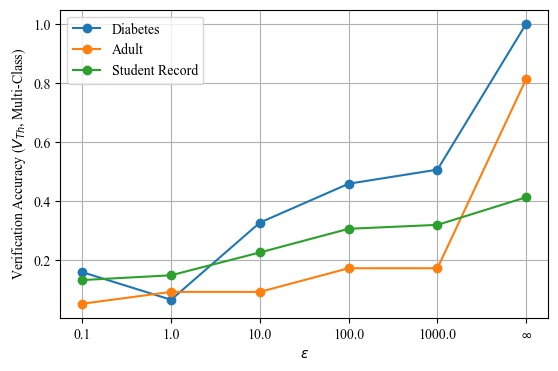

In [5]:
import matplotlib.pyplot as plt

# Configure matplotlib for Times New Roman font and 10-point size
plt.rc('font', family='Times New Roman', size=10)
plt.rc('axes', titlesize=10)  # Font size of the axes title
plt.rc('axes', labelsize=10)  # Font size of the x and y labels
plt.rc('xtick', labelsize=10)  # Font size of the x tick labels
plt.rc('ytick', labelsize=10)  # Font size of the y tick labels
plt.rc('legend', fontsize=10)  # Font size of the legend
plt.rc('figure', titlesize=10)  # Font size of the figure title

dataset_names = {
    '891': 'Diabetes',
    '2': 'Adult',
    '697': 'Student Record'
}

# Plot the results
plt.figure(figsize=(6.3, 4))

for dataset_id in dataset_id_list:
    plt.plot(epsilon_list, accuracy_results[dataset_id], marker='o', label=dataset_names[dataset_id])

# Ensure the ticks align with the data points
plt.xticks(epsilon_list, labels=['0.1', '1.0', '10.0', '100.0', '1000.0', r'$\infty$'])

# Customize the legend text
plt.xlabel(r'$\epsilon$')
plt.ylabel(r'Verification Accuracy ($V_{Th}$, Multi-Class)')
plt.legend(loc='upper left', fontsize=10)  # Custom legend title and location
plt.grid(True)

plt.savefig(f'plot_VTh_Multi_lime_logres.pdf', format='pdf')

plt.show()

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Initialize a dictionary to store accuracies for plotting (14 comparisons for each dataset_id)
pairwise_accuracy_results = {dataset_id: {f"0_vs_{i}": [] for i in range(1, 15)} for dataset_id in dataset_id_list}

# Dictionary to store final averaged accuracies for each dataset and epsilon
final_averaged_accuracies = {dataset_id: [] for dataset_id in dataset_id_list}

for dataset_id in dataset_id_list:
    for epsilon in epsilon_list:
        total_accuracy = 0  # Accumulate accuracy across repeats and pairs

        for rep in repeat_list:  # Outer loop for repeats
            dataframes_train = []
            dataframes_verify = []
            
            for case_id in case_id_list:
                # Construct the exact file names including the repeat number
                file_train = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_CosDist_Train_case{case_id}_rep{rep}.csv')
                file_verify = os.path.join(directory, f'dataset{dataset_id}_eps{epsilon}_CosDist_Verify_case{case_id}_rep{rep}.csv')

                # Check if the file exists before trying to read it
                if os.path.exists(file_train):
                    df_train = pd.read_csv(file_train)
                    dataframes_train.append(df_train)

                if os.path.exists(file_verify):
                    df_verify = pd.read_csv(file_verify)
                    dataframes_verify.append(df_verify)

            if dataframes_train and dataframes_verify:
                df_train = pd.concat(dataframes_train, ignore_index=True)
                df_verify = pd.concat(dataframes_verify, ignore_index=True)

                # Iterate over each incorrect label (1 to 14)
                for incorrect_label in range(1, 15):  
                    # Filter to only keep rows where case is either 0 or the current incorrect_label
                    df_train_pair = df_train[df_train['case'].isin([0, incorrect_label])]
                    df_verify_pair = df_verify[df_verify['case'].isin([0, incorrect_label])]

                    # Step 1: Calculate average cosine distance for each case in the training data
                    average_distances_train = df_train_pair.groupby('case')['Cosine Distance'].mean().reset_index()

                    # Step 2: Calculate average cosine distance for each case in the testing data
                    average_distances_test = df_verify_pair.groupby('case')['Cosine Distance'].mean().reset_index()

                    # Step 3: Compare the average values and predict the case
                    results = []
                    for _, row in average_distances_test.iterrows():
                        true_case = row['case']
                        test_avg = row['Cosine Distance']
                        closest_case = min(
                            average_distances_train.itertuples(),
                            key=lambda x: abs(x._2 - test_avg)
                        )
                        predicted_case = closest_case.case
                        results.append((true_case, predicted_case, test_avg, closest_case._2))

                    results_df = pd.DataFrame(results, columns=['True Case', 'Predicted Case', 'Test Avg Cosine Distance', 'Train Avg Cosine Distance'])
                    
                    # Calculate accuracy for this pair in the current repeat
                    true_cases = results_df['True Case'].astype(int)
                    predicted_cases = results_df['Predicted Case'].astype(int)
                    accuracy = accuracy_score(true_cases, predicted_cases)
                    total_accuracy += accuracy

                    print(f"dataset{dataset_id}_eps{epsilon}_0_vs_{incorrect_label}_rep{rep}")
                    print("Verification Accuracy:", accuracy)

                    # Store accuracy for the pairwise comparison
                    pairwise_accuracy_results[dataset_id][f"0_vs_{incorrect_label}"].append(accuracy)

        # Calculate the average accuracy for all pair comparisons across repeats
        # total_accuracy / (len(repeat_list) * 14) gives average over repeats and pairs
        average_accuracy = total_accuracy / (len(repeat_list) * 14)
        final_averaged_accuracies[dataset_id].append(average_accuracy)

        print(f"Average Verification Accuracy for dataset{dataset_id}_eps{epsilon}: {average_accuracy}")

dataset891_eps0.1_0_vs_1_rep0
Verification Accuracy: 0.0
dataset891_eps0.1_0_vs_2_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_3_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_4_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_5_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_6_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_7_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_8_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_9_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_10_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_11_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_12_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_13_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_14_rep0
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_1_rep1
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_2_rep1
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_3_rep1
Verification Accuracy: 0.5
dataset891_eps0.1_0_vs_4_r

In [7]:
# Convert accuracy_results dictionary to a DataFrame
accuracy_df = pd.DataFrame(final_averaged_accuracies, index=epsilon_list)

# Save to CSV
accuracy_df.to_csv('accuracy_results_lime_logres_vth_binary.csv', index_label='epsilon')

print("Results saved to accuracy_results_lime_logres_vth_binary.csv")

Results saved to accuracy_results_lime_logres_vth_binary.csv


In [8]:
final_averaged_accuracies = pd.read_csv('accuracy_results_lime_logres_vth_binary.csv', index_col='epsilon')

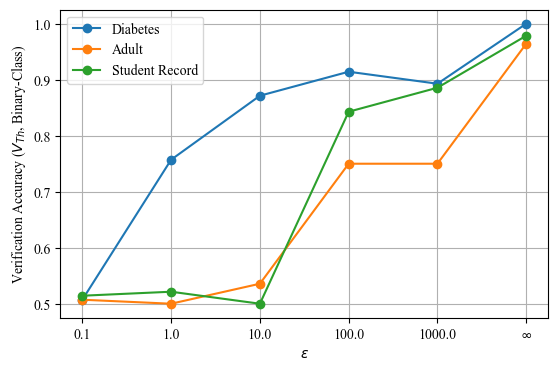

In [9]:
import matplotlib.pyplot as plt

# Configure matplotlib for Times New Roman font and 10-point size
plt.rc('font', family='Times New Roman', size=10)
plt.rc('axes', titlesize=10)  # Font size of the axes title
plt.rc('axes', labelsize=10)  # Font size of the x and y labels
plt.rc('xtick', labelsize=10)  # Font size of the x tick labels
plt.rc('ytick', labelsize=10)  # Font size of the y tick labels
plt.rc('legend', fontsize=10)  # Font size of the legend
plt.rc('figure', titlesize=10)  # Font size of the figure title

# Assuming you have the following dataset names
dataset_names = {
    '891': 'Diabetes',
    '2': 'Adult',
    '697': 'Student Record'
}

# Plot the results
plt.figure(figsize=(6.3, 4))

# Plot the results for each dataset
for dataset_id in dataset_id_list:
    plt.plot(epsilon_list, final_averaged_accuracies[dataset_id], marker='o', label=dataset_names.get(dataset_id, dataset_id))

# Ensure the ticks align with the data points
plt.xticks(epsilon_list, labels=['0.1', '1.0', '10.0', '100.0', '1000.0', r'$\infty$'])

# Customize the legend text and labels
plt.xlabel(r'$\epsilon$')
plt.ylabel(r'Verification Accuracy ($V_{Th}$, Binary-Class)')
plt.legend(loc='upper left', fontsize=10)  # Custom legend title and location
plt.grid(True)

# Optionally, save the plot as a PDF
plt.savefig(f'plot_VTh_Binary_lime_logres.pdf', format='pdf')

plt.show()